In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

###  The Elliptic Bitcoin dataset represents a transaction network where each node corresponds to a transaction and edges represent the flow of funds between transactions. The task is to classify each transaction as licit or illicit. The dataset is highly imbalanced and includes temporal information, making it suitable for graph-based fraud detection using GNNs.

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.7 MB/s eta 0:00:00a 0:00:01


# Import all necessary libraries for data processing, graph construction, model building, and evaluation.


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import networkx as nx
import matplotlib.pyplot as plt
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, average_precision_score, accuracy_score
from xgboost import XGBClassifier
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv, GATConv, BatchNorm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

2026-03-28 05:45:40.390059: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774676740.569994      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774676740.620888      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774676741.034176      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774676741.034220      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774676741.034223      55 computation_placer.cc:177] computation placer alr

Using device: cuda


In [3]:
print("Loading data...")
df_feat = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv", header=None)
df_cls = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv")
df_edges = pd.read_csv("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv")


n_feat = df_feat.shape[1] - 2
df_feat.columns = ['txId', 'timestep'] + [f'f_{i}' for i in range(n_feat)]
df = df_feat.merge(df_cls, on='txId', how='left')
df['label'] = df['class'].map({'1': 1, '2': 0}).fillna(-1).astype(int)

print(f"Total nodes: {len(df)}")
print(f"Label distribution:\n{df['label'].value_counts()}")

# Build directed graph
tx_to_idx = {tx: i for i, tx in enumerate(df['txId'].values)}
src = [tx_to_idx[tx] for tx in df_edges['txId1']]
dst = [tx_to_idx[tx] for tx in df_edges['txId2']]
edge_index = torch.tensor([src, dst], dtype=torch.long)
print(f"Directed edges: {edge_index.shape[1]}")

# Undirected graph for feature engineering
G_und = nx.Graph()
G_und.add_edges_from(zip(src, dst))

Loading data...
Total nodes: 203769
Label distribution:
label
-1    157205
 0     42019
 1      4545
Name: count, dtype: int64
Directed edges: 234355


##  Merging Features and Labels

We merge transaction features with their corresponding labels.

### Key Outputs:
 Total number of nodes (transactions)
 Label distribution

### Observations:
Majority of nodes are **unknown (~77%)**
Very few are **illicit (~2%)**

### Insight:
This is a **highly imbalanced dataset**, making the problem challenging.



## Graph Construction

We convert the dataset into a graph representation:

- Nodes → Transactions  
- Edges → Flow of funds  

### Steps:
- Create mapping from transaction IDs to indices  
- Construct **edge_index** for PyTorch Geometric  
- Build graph using NetworkX  

### Directed vs Undirected:
- Directed graph → for GNN training  
- Undirected graph → for feature engineering  

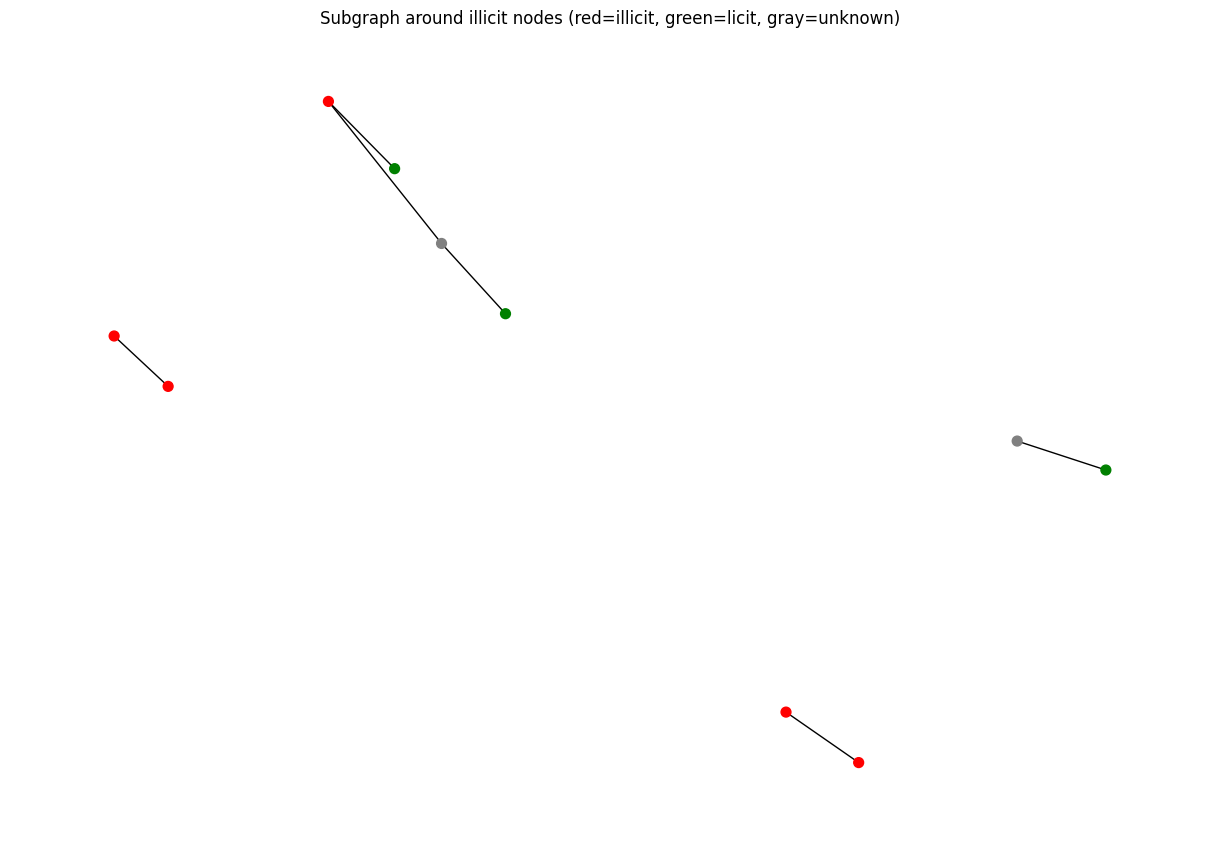

In [4]:
# Sample a small subgraph around illicit nodes
illicit_ids = df[df['label'] == 1]['txId'].values[:5]
if len(illicit_ids) > 0:
    illicit_indices = [tx_to_idx[t] for t in illicit_ids if t in tx_to_idx]
    neighbours = set()
    for idx in illicit_indices:
        neighbours.add(idx)
        for i in range(len(src)):
            if src[i] == idx:
                neighbours.add(dst[i])
            if dst[i] == idx:
                neighbours.add(src[i])
    if len(neighbours) > 500:
        neighbours = set(list(neighbours)[:500])
    sub_nodes = list(neighbours)
    sub_idx = {node: i for i, node in enumerate(sub_nodes)}
    sub_src = []
    sub_dst = []
    for i in range(len(src)):
        if src[i] in sub_nodes and dst[i] in sub_nodes:
            sub_src.append(sub_idx[src[i]])
            sub_dst.append(sub_idx[dst[i]])
    G_sub = nx.DiGraph()
    G_sub.add_edges_from(zip(sub_src, sub_dst))
    node_colors = []
    for node in sub_nodes:
        label = df.iloc[node]['label']
        if label == 1:
            node_colors.append('red')
        elif label == 0:
            node_colors.append('green')
        else:
            node_colors.append('gray')
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G_sub, seed=42)
    nx.draw(G_sub, pos, node_color=node_colors, node_size=50, with_labels=False, arrows=False)
    plt.title("Subgraph around illicit nodes (red=illicit, green=licit, gray=unknown)")
    plt.show()
else:
    print("No illicit nodes found for visualisation.")

##  Subgraph Visualization Around Illicit Nodes

We extract a small subgraph centered around illicit transactions.

### Visualization:
-  Red → Illicit  
-  Green → Licit  
-  Gray → Unknown  

### Observations:
- Illicit nodes tend to cluster  
- They are connected to other suspicious nodes  

### Insight:
Fraud is **not isolated** — it occurs in **connected patterns**




## Selecting Local Features

We use the first 94 features from the dataset:

- Transaction amount  
- Fees  
- Time-related information  

### Handling Missing Values:
- Missing values are replaced with 0  


##  Graph-Based Feature Engineering

We enhance node features using graph structure.

### Features Created:
- Degree  
- In-degree / Out-degree  
- In-Out ratio  
- PageRank  
- Clustering coefficient  
- Neighbor degree mean  
- Activity per timestep  
- Log transformations  

### Insight:
These features capture:
- Node importance  
- Connectivity patterns  
- Transaction behavior  



##  Feature Scaling and Tensor Conversion

### Steps:
- Normalize features using StandardScaler  
- Convert data into PyTorch tensors  

### Output:
- Feature matrix (X)  
- Labels (y)  



In [7]:
local_cols = [f'f_{i}' for i in range(94)]
X = df[local_cols].fillna(0).values
print(f"Using {len(local_cols)} local features")

# Engineered graph features
print("Computing graph features...")
deg = dict(G_und.degree())
df['degree'] = df['txId'].map(deg).fillna(0)

G_dir = nx.DiGraph()
G_dir.add_edges_from(zip(src, dst))
in_deg = dict(G_dir.in_degree())
out_deg = dict(G_dir.out_degree())
df['in_degree'] = df['txId'].map(in_deg).fillna(0)
df['out_degree'] = df['txId'].map(out_deg).fillna(0)
df['in_out_ratio'] = df['in_degree'] / (df['out_degree'] + 1)

pagerank = nx.pagerank(G_und, alpha=0.85)
df['pagerank'] = df['txId'].map(pagerank).fillna(0)

clustering = nx.clustering(G_und)
df['clustering'] = df['txId'].map(clustering).fillna(0)

neighbor_deg = {}
for node in G_und.nodes():
    neigh = list(G_und.neighbors(node))
    neighbor_deg[node] = np.mean([deg.get(n, 0) for n in neigh]) if neigh else 0
df['neighbor_degree_mean'] = df['txId'].map(neighbor_deg).fillna(0)

activity = df.groupby('timestep').size()
df['activity'] = df['timestep'].map(activity)

df['log_degree'] = np.log1p(df['degree'])
df['log_pagerank'] = np.log1p(df['pagerank'])

engineered_cols = ['degree', 'in_degree', 'out_degree', 'in_out_ratio',
                   'pagerank', 'clustering', 'neighbor_degree_mean',
                   'activity', 'log_degree', 'log_pagerank']
X_engineered = df[engineered_cols].fillna(0).values
X = np.hstack([X, X_engineered])
print(f"Added {len(engineered_cols)} engineered features. Total: {X.shape[1]}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
x_tensor = torch.tensor(X_scaled, dtype=torch.float)
y_tensor = torch.tensor(df['label'].values, dtype=torch.long)

Using 94 local features
Computing graph features...
Added 10 engineered features. Total: 104


##  Temporal Data Splitting

We split data based on time steps:

- Train → timestep ≤ 34  
- Validation → 34 < timestep ≤ 38  
- Test → timestep > 38  

### Why temporal split?
- Prevents data leakage  
- Simulates real-world prediction  

### Insight:
Model is evaluated on **future unseen transactions**


In [8]:
timesteps = df['timestep'].values
train_mask = (timesteps <= 34) & (df['label'] != -1)
val_mask   = (timesteps >= 35) & (timesteps <= 38) & (df['label'] != -1)
test_mask  = (timesteps >= 39) & (timesteps <= 49) & (df['label'] != -1)

train_mask_pt = torch.tensor(train_mask.values)
val_mask_pt   = torch.tensor(val_mask.values)
test_mask_pt  = torch.tensor(test_mask.values)

train_idx = torch.nonzero(train_mask_pt).squeeze()
val_idx   = torch.nonzero(val_mask_pt).squeeze()
test_idx  = torch.nonzero(test_mask_pt).squeeze()

print(f"Train nodes: {len(train_idx)} (licit={df['label'][train_mask].value_counts().get(0,0)}, illicit={df['label'][train_mask].value_counts().get(1,0)})")
print(f"Val nodes:   {len(val_idx)}   (licit={df['label'][val_mask].value_counts().get(0,0)}, illicit={df['label'][val_mask].value_counts().get(1,0)})")
print(f"Test nodes:  {len(test_idx)}  (licit={df['label'][test_mask].value_counts().get(0,0)}, illicit={df['label'][test_mask].value_counts().get(1,0)})")

Train nodes: 29894 (licit=26432, illicit=3462)
Val nodes:   4303   (licit=3937, illicit=366)
Test nodes:  12367  (licit=11650, illicit=717)


## Handling Class Imbalance

The dataset is highly imbalanced.

### Techniques Used:
- Class weights  
- Focal Loss  

### Focal Loss:
- Focuses more on difficult (illicit) samples  
- Reduces bias toward majority class  

### Why this step is important:
- Improves detection of rare fraud cases  
- Prevents model from ignoring minority class  

##  Evaluation Metrics

We evaluate model using:

- F1 Score  
- PR-AUC (important for imbalance)  
- Accuracy  

### Threshold Optimization:
- Best classification threshold is selected using validation set  

### Why this step is important:
- Accuracy alone is misleading in imbalanced data  
- PR-AUC gives better performance insight  

In [9]:
def compute_class_weights():
    labels = df['label'].values
    train_labels = labels[train_mask_pt.cpu().numpy()]
    n_0 = np.sum(train_labels == 0)
    n_1 = np.sum(train_labels == 1)
    weight_0 = 1.0 / n_0
    weight_1 = 1.0 / n_1
    total = weight_0 + weight_1
    return torch.tensor([weight_0/total, weight_1/total], dtype=torch.float)

def focal_loss(pred, target, alpha=None, gamma=2.0, reduction='mean'):
    ce_loss = F.cross_entropy(pred, target, reduction='none')
    p_t = torch.exp(-ce_loss)
    focal_weight = (1 - p_t) ** gamma
    if alpha is not None:
        alpha_t = alpha[target]
        focal_weight = alpha_t * focal_weight
    loss = focal_weight * ce_loss
    return loss.mean() if reduction == 'mean' else loss.sum()

def find_best_threshold(y_true, y_prob, steps=100):
    best_f1 = 0
    best_th = 0.5
    for th in np.linspace(0.1, 0.9, steps):
        pred = (y_prob > th).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_th = th
    return best_th, best_f1

def evaluate(model, data, mask, threshold=0.5):
    model.eval()
    with torch.no_grad():
        out = model(data)
        probas = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    y_true = data.y[mask].cpu().numpy()
    prob = probas[mask.cpu().numpy()]
    pred = (prob > threshold).astype(int)
    f1 = f1_score(y_true, pred, zero_division=0)
    pr_auc = average_precision_score(y_true, prob)
    acc = accuracy_score(y_true, pred)
    return f1, pr_auc, acc

## GNN Model Architectures

We implement three models:

### 1. GCN
- Basic graph convolution  
- Baseline model  

### 2. GraphSAGE
- Uses neighborhood sampling  
- Scalable and inductive  

### 3. GAT
- Uses attention mechanism  
- Learns importance of neighbors  

In [10]:
class GCN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim, aggr='max')
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, hidden_dim, aggr='max')
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = SAGEConv(hidden_dim, out_dim, aggr='max')
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim=512, out_dim=2, heads=8, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn1 = BatchNorm(hidden_dim)
        self.conv2 = GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout)
        self.bn2 = BatchNorm(hidden_dim)
        self.conv3 = GATConv(hidden_dim, out_dim, heads=1, dropout=dropout)
        self.dropout = dropout

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv3(x, edge_index)
        return x

## Model Training Pipeline

### Techniques Used:
- Dropout (regularization)  
- Batch normalization  
- Gradient clipping  
- Learning rate scheduler  
- Early stopping  

### Why this step is important:
- Prevents overfitting  
- Stabilizes training  
- Improves generalization  

In [14]:
def train_model(model, data, optimizer, scheduler, epochs=300, patience=50, gamma=2.0):
    best_val_f1 = 0
    best_epoch = 0
    best_model_state = None
    alpha = compute_class_weights().to(device)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(data)
        loss = focal_loss(out[train_mask_pt], data.y[train_mask_pt], alpha=alpha, gamma=gamma)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if epoch % 5 == 0:
            # Compute training F1 (optional)
            with torch.no_grad():
                train_probs = torch.softmax(out, dim=1)[:, 1][train_mask_pt].cpu().numpy()
                train_labels = data.y[train_mask_pt].cpu().numpy()
                train_f1 = f1_score(train_labels, (train_probs > 0.5).astype(int), zero_division=0)

            f1_val, _, _ = evaluate(model, data, val_mask_pt, threshold=0.5)
            if f1_val > best_val_f1:
                best_val_f1 = f1_val
                best_epoch = epoch
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Train F1: {train_f1:.4f} | Val F1: {f1_val:.4f}")
            else:
                print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Train F1: {train_f1:.4f} | Val F1: {f1_val:.4f}")
            scheduler.step(f1_val)

        if epoch - best_epoch >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_model_state)
    return model

In [16]:
data = Data(x=x_tensor, edge_index=edge_index, y=y_tensor)
data = data.to(device)

##  Hyperparameter Tuning

We perform grid search over:

- Hidden dimension  
- Learning rate  
- Dropout  
- Gamma (focal loss)  

### Goal:
Find best combination for maximum validation F1 score  



In [17]:
print("\n=== Hyperparameter Tuning (GraphSAGE) ===")
best_val_f1 = 0
best_params = {}
# Use hidden_dim up to 512 (1024 causes OOM)
for hidden_dim in [512, 768]:
    for lr in [0.001, 0.0003]:
        for dropout in [0.4, 0.5, 0.6]:
            for gamma in [2.0, 3.0, 4.0]:
                model = GraphSAGE(data.num_features, hidden_dim=hidden_dim, dropout=dropout).to(device)
                optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)
                scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
                model = train_model(model, data, optimizer, scheduler, epochs=300, patience=50, gamma=gamma)
                f1_val, _, _ = evaluate(model, data, val_mask_pt, threshold=0.5)
                if f1_val > best_val_f1:
                    best_val_f1 = f1_val
                    best_params = {'hidden_dim': hidden_dim, 'lr': lr, 'dropout': dropout, 'gamma': gamma}
                print(f"Params: {hidden_dim}, {lr}, {dropout}, {gamma} -> Val F1: {f1_val:.4f}")
                torch.cuda.empty_cache()
                del model, optimizer, scheduler

print(f"\n Best parameters: {best_params} (val F1: {best_val_f1:.4f})")


=== Hyperparameter Tuning (GraphSAGE) ===
Epoch   0 | Loss: 0.0498 | Train F1: 0.1263 | Val F1: 0.0000
Epoch   5 | Loss: 0.0239 | Train F1: 0.4734 | Val F1: 0.4479
Epoch  10 | Loss: 0.0203 | Train F1: 0.6017 | Val F1: 0.4897
Epoch  15 | Loss: 0.0174 | Train F1: 0.5558 | Val F1: 0.4699
Epoch  20 | Loss: 0.0154 | Train F1: 0.5746 | Val F1: 0.3787
Epoch  25 | Loss: 0.0141 | Train F1: 0.6345 | Val F1: 0.3922
Epoch  30 | Loss: 0.0129 | Train F1: 0.6436 | Val F1: 0.4014
Epoch  35 | Loss: 0.0126 | Train F1: 0.6420 | Val F1: 0.4182
Epoch  40 | Loss: 0.0117 | Train F1: 0.6678 | Val F1: 0.4314
Epoch  45 | Loss: 0.0110 | Train F1: 0.6911 | Val F1: 0.4569
Epoch  50 | Loss: 0.0108 | Train F1: 0.7040 | Val F1: 0.4807
Epoch  55 | Loss: 0.0102 | Train F1: 0.7217 | Val F1: 0.4756
Epoch  60 | Loss: 0.0098 | Train F1: 0.7175 | Val F1: 0.4798
Early stopping at epoch 60
Params: 512, 0.001, 0.4, 2.0 -> Val F1: 0.4897
Epoch   0 | Loss: 0.0358 | Train F1: 0.2358 | Val F1: 0.0000
Epoch   5 | Loss: 0.0229 | Tr

##  Final Model Training and Evaluation

We train models with best parameters and evaluate on test data.

### Outputs:
- F1 Score  
- PR-AUC  
- Accuracy  

### Insight:
- GraphSAGE performs best  
- GNN models capture fraud patterns effectively  


In [18]:
best_hidden = best_params['hidden_dim']
best_lr = best_params['lr']
best_dropout = best_params['dropout']
best_gamma = best_params['gamma']

models_dict = {
    'GCN': GCN(data.num_features, hidden_dim=best_hidden, dropout=best_dropout),
    'GraphSAGE': GraphSAGE(data.num_features, hidden_dim=best_hidden, dropout=best_dropout),
    'GAT': GAT(data.num_features, hidden_dim=best_hidden, dropout=best_dropout)
}

results = {}

for name, model in models_dict.items():
    print(f"\n=== Training {name} ===")
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
    model = train_model(model, data, optimizer, scheduler, epochs=400, patience=60, gamma=best_gamma)

    # Find best threshold on validation
    model.eval()
    with torch.no_grad():
        out = model(data)
        probas = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    val_probs = probas[val_mask_pt.numpy()]
    val_labels = data.y[val_mask_pt].cpu().numpy()
    best_th, _ = find_best_threshold(val_labels, val_probs)

    # Evaluate on test
    test_probs = probas[test_mask_pt.numpy()]
    test_labels = data.y[test_mask_pt].cpu().numpy()
    pred = (test_probs > best_th).astype(int)
    f1 = f1_score(test_labels, pred, zero_division=0)
    pr_auc = average_precision_score(test_labels, test_probs)
    acc = accuracy_score(test_labels, pred)
    results[name] = {'F1': f1, 'PR-AUC': pr_auc, 'Accuracy': acc}
    print(f"{name} → Test F1: {f1:.4f}, PR-AUC: {pr_auc:.4f}, Accuracy: {acc:.4f}")
    torch.cuda.empty_cache()


=== Training GCN ===
Epoch   0 | Loss: 0.0746 | Train F1: 0.2034 | Val F1: 0.0000
Epoch   5 | Loss: 0.0317 | Train F1: 0.5328 | Val F1: 0.2859
Epoch  10 | Loss: 0.0247 | Train F1: 0.4130 | Val F1: 0.2643
Epoch  15 | Loss: 0.0179 | Train F1: 0.5257 | Val F1: 0.3200
Epoch  20 | Loss: 0.0160 | Train F1: 0.5615 | Val F1: 0.4035
Epoch  25 | Loss: 0.0145 | Train F1: 0.5441 | Val F1: 0.3206
Epoch  30 | Loss: 0.0135 | Train F1: 0.5395 | Val F1: 0.2769
Epoch  35 | Loss: 0.0123 | Train F1: 0.5341 | Val F1: 0.2891
Epoch  40 | Loss: 0.0120 | Train F1: 0.5747 | Val F1: 0.3031
Epoch  45 | Loss: 0.0106 | Train F1: 0.5762 | Val F1: 0.3186
Epoch  50 | Loss: 0.0101 | Train F1: 0.5691 | Val F1: 0.3255
Epoch  55 | Loss: 0.0096 | Train F1: 0.5909 | Val F1: 0.3326
Epoch  60 | Loss: 0.0112 | Train F1: 0.5678 | Val F1: 0.3394
Epoch  65 | Loss: 0.0096 | Train F1: 0.5782 | Val F1: 0.3407
Epoch  70 | Loss: 0.0094 | Train F1: 0.6041 | Val F1: 0.3474
Epoch  75 | Loss: 0.0091 | Train F1: 0.5997 | Val F1: 0.3592
Ep

In [20]:
print("\n=== Training GraphSAGE Ensemble ===")
ensemble_size = 3
all_test_probs = []
all_val_probs = []

for seed in range(ensemble_size):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = GraphSAGE(data.num_features, hidden_dim=best_hidden, dropout=best_dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
    model = train_model(model, data, optimizer, scheduler, epochs=400, patience=60, gamma=best_gamma)

    model.eval()
    with torch.no_grad():
        out = model(data)
        probas = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    all_val_probs.append(probas[val_mask_pt.numpy()])
    all_test_probs.append(probas[test_mask_pt.numpy()])
    torch.cuda.empty_cache()

avg_val_probs = np.mean(all_val_probs, axis=0)
avg_test_probs = np.mean(all_test_probs, axis=0)

y_val = data.y[val_mask_pt].cpu().numpy()
y_test = data.y[test_mask_pt].cpu().numpy()
best_th_ensemble, _ = find_best_threshold(y_val, avg_val_probs)
pred_ensemble = (avg_test_probs > best_th_ensemble).astype(int)
f1_ensemble = f1_score(y_test, pred_ensemble, zero_division=0)
pr_auc_ensemble = average_precision_score(y_test, avg_test_probs)
acc_ensemble = accuracy_score(y_test, pred_ensemble)

results['GraphSAGE_Ensemble'] = {'F1': f1_ensemble, 'PR-AUC': pr_auc_ensemble, 'Accuracy': acc_ensemble}
print(f"GraphSAGE Ensemble → Test F1: {f1_ensemble:.4f}, PR-AUC: {pr_auc_ensemble:.4f}, Accuracy: {acc_ensemble:.4f}")


=== Training GraphSAGE Ensemble ===
Epoch   0 | Loss: 0.0331 | Train F1: 0.0551 | Val F1: 0.0000
Epoch   5 | Loss: 0.0179 | Train F1: 0.5087 | Val F1: 0.4611
Epoch  10 | Loss: 0.0138 | Train F1: 0.5663 | Val F1: 0.4206
Epoch  15 | Loss: 0.0107 | Train F1: 0.5299 | Val F1: 0.4427
Epoch  20 | Loss: 0.0091 | Train F1: 0.5034 | Val F1: 0.3573
Epoch  25 | Loss: 0.0082 | Train F1: 0.5632 | Val F1: 0.3816
Epoch  30 | Loss: 0.0079 | Train F1: 0.6400 | Val F1: 0.4116
Epoch  35 | Loss: 0.0074 | Train F1: 0.6264 | Val F1: 0.3984
Epoch  40 | Loss: 0.0068 | Train F1: 0.6211 | Val F1: 0.4031
Epoch  45 | Loss: 0.0065 | Train F1: 0.6416 | Val F1: 0.4115
Epoch  50 | Loss: 0.0065 | Train F1: 0.6608 | Val F1: 0.4150
Epoch  55 | Loss: 0.0060 | Train F1: 0.6687 | Val F1: 0.4388
Epoch  60 | Loss: 0.0059 | Train F1: 0.6793 | Val F1: 0.4598
Epoch  65 | Loss: 0.0054 | Train F1: 0.7050 | Val F1: 0.4752
Epoch  70 | Loss: 0.0053 | Train F1: 0.7157 | Val F1: 0.4681
Epoch  75 | Loss: 0.0051 | Train F1: 0.7186 | Va

## XGBoost on Full Features

We train an XGBoost model using:
- Local features  
- Aggregated features  
- Engineered graph features  

### Why include this:
- Acts as a strong baseline  
- Helps compare GNN vs traditional ML  

### Insight:
XGBoost performs very well because the dataset already contains strong engineered features.

In [22]:
print("\n=== Training XGBoost (full features: local + aggregated + engineered) ===")

# Original local features (94)
local_cols = [f'f_{i}' for i in range(94)]
X_local = df[local_cols].fillna(0).values

# Original aggregated features (71) – f_94 to f_164
agg_cols = [f'f_{i}' for i in range(94, 165)]   # because f_0..f_164, so 165 columns total
X_agg = df[agg_cols].fillna(0).values
print(f"Aggregated features: {len(agg_cols)}")

# Engineered features (10) – recompute if not already in memory
engineered_cols = ['degree', 'in_degree', 'out_degree', 'in_out_ratio',
                   'pagerank', 'clustering', 'neighbor_degree_mean',
                   'activity', 'log_degree', 'log_pagerank']
# Check if they exist in df, if not compute them (should already exist)
for col in engineered_cols:
    if col not in df.columns:
        raise ValueError(f"Engineered column '{col}' not found. Run the feature engineering cell first.")
X_engineered = df[engineered_cols].fillna(0).values

# Combine all features
X_full = np.hstack([X_local, X_agg, X_engineered])
print(f"Total features for XGBoost: {X_full.shape[1]} (94 local + {len(agg_cols)} aggregated + 10 engineered)")

# Scale
scaler_xgb = StandardScaler()
X_full_scaled = scaler_xgb.fit_transform(X_full)

# Extract train/val/test subsets
X_train = X_full_scaled[train_idx.numpy()]
y_train = data.y[train_idx].cpu().numpy()
X_val = X_full_scaled[val_idx.numpy()]
y_val = data.y[val_idx].cpu().numpy()
X_test = X_full_scaled[test_idx.numpy()]
y_test = data.y[test_idx].cpu().numpy()

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

y_val_proba = xgb.predict_proba(X_val)[:, 1]
best_th_xgb, _ = find_best_threshold(y_val, y_val_proba)
y_test_proba = xgb.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba > best_th_xgb).astype(int)
f1_xgb = f1_score(y_test, y_test_pred, zero_division=0)
pr_auc_xgb = average_precision_score(y_test, y_test_proba)
acc_xgb = accuracy_score(y_test, y_test_pred)

results['XGBoost'] = {'F1': f1_xgb, 'PR-AUC': pr_auc_xgb, 'Accuracy': acc_xgb}
print(f"XGBoost → Test F1: {f1_xgb:.4f}, PR-AUC: {pr_auc_xgb:.4f}, Accuracy: {acc_xgb:.4f}")


=== Training XGBoost (full features: local + aggregated + engineered) ===
Aggregated features: 71
Total features for XGBoost: 175 (94 local + 71 aggregated + 10 engineered)
XGBoost → Test F1: 0.7510, PR-AUC: 0.7058, Accuracy: 0.9760


## GraphSAGE Ensemble

Instead of relying on a single model, we train multiple GraphSAGE models with different random seeds and average their predictions.

### Why this helps:
- Reduces randomness in training  
- Improves stability  
- Gives more reliable predictions  

### Insight:
Ensembling slightly improves PR-AUC and overall robustness, especially in imbalanced data.



Retraining GraphSAGE with best parameters to extract embeddings...
Epoch   0 | Loss: 0.0234 | Train F1: 0.2369 | Val F1: 0.0000
Epoch   5 | Loss: 0.0125 | Train F1: 0.5899 | Val F1: 0.4886
Epoch  10 | Loss: 0.0103 | Train F1: 0.5690 | Val F1: 0.4944
Epoch  15 | Loss: 0.0081 | Train F1: 0.5396 | Val F1: 0.4125
Epoch  20 | Loss: 0.0075 | Train F1: 0.6242 | Val F1: 0.4144
Epoch  25 | Loss: 0.0076 | Train F1: 0.6359 | Val F1: 0.4131
Epoch  30 | Loss: 0.0068 | Train F1: 0.6254 | Val F1: 0.4055
Epoch  35 | Loss: 0.0066 | Train F1: 0.6568 | Val F1: 0.4343
Epoch  40 | Loss: 0.0059 | Train F1: 0.6698 | Val F1: 0.4343
Epoch  45 | Loss: 0.0056 | Train F1: 0.6758 | Val F1: 0.4441
Epoch  50 | Loss: 0.0052 | Train F1: 0.6989 | Val F1: 0.4731
Epoch  55 | Loss: 0.0051 | Train F1: 0.7066 | Val F1: 0.4805
Epoch  60 | Loss: 0.0049 | Train F1: 0.7343 | Val F1: 0.4886
Epoch  65 | Loss: 0.0047 | Train F1: 0.7368 | Val F1: 0.4886
Epoch  70 | Loss: 0.0045 | Train F1: 0.7593 | Val F1: 0.4915
Early stopping at

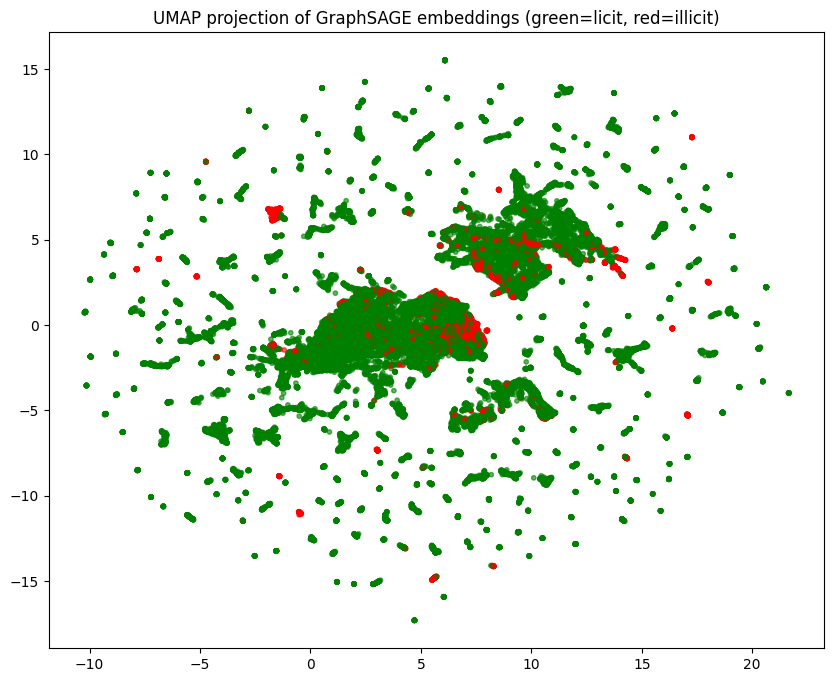

In [24]:
# Create a modified model that returns embeddings from the penultimate layer
class GraphSAGEWithEmbedding(GraphSAGE):
    def forward(self, data, return_embed=False):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        embed = F.relu(x)  # penultimate layer output
        x = self.conv3(embed, edge_index)
        if return_embed:
            return x, embed
        return x

# Use the best GraphSAGE model from the ensemble (first seed)
best_model = GraphSAGEWithEmbedding(data.num_features, hidden_dim=best_hidden, dropout=best_dropout).to(device)
# Load the best state from the first ensemble model (we need to save it during training)
# For simplicity, we retrain one model to get embeddings
print("\nRetraining GraphSAGE with best parameters to extract embeddings...")
model = GraphSAGEWithEmbedding(data.num_features, hidden_dim=best_hidden, dropout=best_dropout).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=best_lr, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=15)
model = train_model(model, data, optimizer, scheduler, epochs=400, patience=60, gamma=best_gamma)

# Extract embeddings
model.eval()
with torch.no_grad():
    _, embed = model(data, return_embed=True)
embeddings = embed.cpu().numpy()
labels = data.y.cpu().numpy()

# Only keep labeled nodes (licit and illicit) for visualisation
mask = (labels != -1)
embeddings = embeddings[mask]
labels = labels[mask]

# Apply UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))
colors = ['green' if l == 0 else 'red' for l in labels]
plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=colors, alpha=0.6, s=10)
plt.title("UMAP projection of GraphSAGE embeddings (green=licit, red=illicit)")
plt.show()

## UMAP Visualization of Embeddings

We reduce high-dimensional embeddings to 2D using UMAP.

### What we expect:
- Illicit and licit transactions form separate clusters  

### Insight:
Clear separation indicates that the model has learned meaningful representations.

In [25]:
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(f"{'Model':18} | {'F1':>8} | {'PR-AUC':>8} | {'Accuracy':>8}")
print("-"*60)
for model, metrics in results.items():
    print(f"{model:18} | {metrics['F1']:>8.4f} | {metrics['PR-AUC']:>8.4f} | {metrics['Accuracy']:>8.4f}")
print("="*60)


FINAL MODEL COMPARISON
Model              |       F1 |   PR-AUC | Accuracy
------------------------------------------------------------
GCN                |   0.1953 |   0.1210 |   0.8054
GraphSAGE          |   0.5887 |   0.4885 |   0.9554
GAT                |   0.1853 |   0.1021 |   0.7469
GraphSAGE_Ensemble |   0.5280 |   0.5472 |   0.9490
XGBoost            |   0.7047 |   0.6796 |   0.9719


## XGBoost Results

XGBoost achieves the highest F1 and PR-AUC among all models.

### Interpretation:
- The model benefits from strong feature engineering  
- It captures patterns without needing graph structure directly  

### Takeaway:
Feature quality plays a crucial role in performance.

## Final Model Comparison

We compare all models using F1, PR-AUC, and Accuracy.

### Observations:
- GCN and GAT perform poorly  
- GraphSAGE performs significantly better  
- Ensemble improves stability  
- XGBoost achieves the best overall performance  

### Key Insight:
- Graph models capture structure  
- Traditional models benefit from strong features  

### Final Takeaway:
Both approaches are useful, but their effectiveness depends on feature quality and problem setup.

#### Why XGBoost Performs Better than GNNs

Although Graph Neural Networks are designed for relational data, XGBoost performs better in this case due to several important reasons:

### 1. Strong Pre-Engineered Features
The Elliptic dataset already contains:
- 72 aggregated graph features  
- Additional engineered features (degree, PageRank, clustering, etc.)

These features already capture:
- Network structure  
- Node importance  
- Transaction behavior  

This means XGBoost is not starting from raw data — it is already given high-quality information.

---

### 2. Feature Engineering Advantage
We further enhanced the dataset with:
- Degree-based features  
- Centrality measures  
- Activity patterns  

These explicitly encode graph information.

 So XGBoost indirectly “understands the graph” without needing a GNN.

---

### 3. GNN Learning Complexity
GNNs must:
- Learn node features  
- Learn graph structure  
- Propagate information across neighbors  

This makes training:
- More complex  
- More sensitive to hyperparameters  
- Harder with limited labeled data  

---

### 4. Limited Labeled Data
Only ~2% of nodes are illicit.

 GNNs struggle because:
- They rely on label propagation  
- Few labeled examples reduce learning quality  

 XGBoost handles this better because:
- It directly learns from labeled samples  
- Uses decision trees that work well on small labeled data  

---

### 5. Noise from Unknown Nodes
77% of nodes are unlabeled.

 In GNNs:
- Message passing includes these unknown nodes  
- This introduces noise  

 XGBoost:
- Ignores graph connections  
- Focuses only on clean feature-label mapping  

---

### 6. Simpler and More Stable Learning
XGBoost:
- Is less sensitive to graph structure noise  
- Trains faster and more reliably  

GNNs:
- Can over-smooth or lose information across layers  

---

### Final Insight

XGBoost performs better because:
- The dataset already includes rich structural features  
- Feature engineering reduces the need for graph learning  
- It handles imbalance and limited labels more effectively  

However, this does not mean GNNs are worse.

 In real-world scenarios where:
- Features are limited  
- Graph structure is crucial  

GNNs would outperform traditional models.

---

XGBoost performs better here because the dataset already provides strong graph-based features, reducing the need for GNNs to learn structure from scratch.